In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scipy
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
from collections import Counter
from Bio import Align
from Bio import SeqIO
from Bio.Align import PairwiseAligner
import pysam
from difflib import SequenceMatcher
import scipy.sparse as sp
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick

sc.settings.verbosity = 2
# sc.logging.print_header()

# Load data

In [4]:
%%time

fpath = "/scratch/indikar_root/indikar1/shared_data/HYB/endo_vs_exo/processed_all_groups_wExoEndo_v2.h5ad"

adata = sc.read_h5ad(fpath)
adata

CPU times: user 667 ms, sys: 2.04 s, total: 2.71 s
Wall time: 16.1 s


AnnData object with n_obs × n_vars = 16296 × 25128
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [5]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
regev_genes = [g for g in regev_genes if g in adata.var_names]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

adata.X = adata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs[['phase']].head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:01)
computing score 'G2M_score'
    finished (0:00:01)
CPU times: user 2.3 s, sys: 1.93 s, total: 4.22 s
Wall time: 4.26 s


,phase
AAACCAAAGCAACTGC_hybrid,G2M
AAACCAAAGTAGGGCA_hybrid,G2M
AAACCAAAGTCTAGGC_hybrid,G1
AAACCATTCACGTAAT_hybrid,G2M
AAACCATTCAGGCAGA_hybrid,G2M


# Load cell cycle genes

In [3]:
# ### --------- load cell cycle genes ---------

# # regev
# regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
# print(f'Total regev genes: {len(regev_genes)}')

# s_genes = regev_genes[:43]
# g2m_genes = regev_genes[43:]

# regev_genes = [g for g in regev_genes if g in adata.var_names]
# print(f'\tDetected in adata: {len(regev_genes)}')


# # GO
# cdf = pd.read_csv("../../resources/human_cell_cycle_genes.csv")
# cc_genes = cdf['gene_name'].unique()
# print(f'\nTotal GO cell cycle genes: {len(cc_genes)}')
# cc_genes = [g for g in cc_genes if g in adata.var_names]
# print(f'\tDetected in adata: {len(cc_genes)}')


# all_cc_genes = list(set(regev_genes) | set(cc_genes))
# print(f'\nGenes in combined list: {len(all_cc_genes)}')

Total regev genes: 97
	Detected in adata: 94

Total GO cell cycle genes: 142
	Detected in adata: 120

Genes in combined list: 210


In [6]:
### --------- load cell cycle genes ---------

# regev
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
print(f'Total regev genes: {len(regev_genes)}')


# GO
cdf = pd.read_csv("../../resources/human_cell_cycle_genes.csv")
cc_genes = cdf['gene_name'].unique()
print(f'\nTotal GO cell cycle genes: {len(cc_genes)}')


# KEGG (hsa04110) -- downloaded from GSEA website
kdf = pd.read_json("../../resources/KEGG_CELL_CYCLE.v2026.1.Hs.json")
kegg_genes = kdf.loc['geneSymbols', 'KEGG_CELL_CYCLE']
print(f'\nTotal KEGG cell cycle genes: {len(kegg_genes)}')


### combine into single list
all_cc_genes = list(set(regev_genes) | set(cc_genes) | set(kegg_genes))
print(f'\nGenes in combined list: {len(all_cc_genes)}')


all_cc_genes = [g for g in all_cc_genes if g in adata.var_names]
print(len(all_cc_genes))

Total regev genes: 97

Total GO cell cycle genes: 142

Total KEGG cell cycle genes: 125

Genes in combined list: 321
293


# Bin MYOD expression level

In [7]:
### ------ get EXO/ENDO + regular MYOD1 counts ------

adata.X = adata.layers['log_norm'].copy()


genes = ['MYOD1_exo', 'MYOD1_endo', 'MYOD1']

mdata = adata[:, genes].copy()
print(mdata.shape)


X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

df = pd.DataFrame(
        X,
        index=mdata.obs_names,
        columns=mdata.var_names,
    )


df = df.reset_index(names='cell_id')
print(df.shape)
df.head()


tmp = adata.obs[['pooled_condition', 'leiden_split', 'phase']].copy()

tmp = tmp.reset_index(names='cell_id')


df1 = pd.merge(df, tmp, how='left', on='cell_id')
print(df1.shape)
df1.head()

(16296, 3)
(16296, 4)
(16296, 7)


,cell_id,MYOD1_exo,MYOD1_endo,MYOD1,pooled_condition,leiden_split,phase
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,2.299394,siPRRX1/mmMYOD1,H1,G2M
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,1.630238,mmMYOD1,M1,G2M
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,1.134289,siPRRX1/mmMYOD1,H1,G1
3,AAACCATTCACGTAAT_hybrid,0.000000,0.000000,0.000000,siPRRX1,P1,G2M
4,AAACCATTCAGGCAGA_hybrid,0.000000,0.000000,0.000000,siPRRX1,P1,G2M


In [14]:
### 
# group cells by HIGH / LOW MYOD1 expression
pdf = df1.copy()

pdf['avg_MYOD1'] = (pdf['MYOD1_exo'] + pdf['MYOD1_endo']) / 2


print("Total MYOD1 expression:")
print(f"Mean = {pdf['avg_MYOD1'].mean():.4f}, Median = {pdf['avg_MYOD1'].median()}\n")

print("Among positive MYOD1 expression:")
print(f"Mean = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].mean():.4f}, Median = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].median():.4f}\n")


# exp_bins = ['NE', 'low', 'med', 'high']


# pdf["exp_level"] = "NE"


cond_col = "pooled_condition" 
labels = ["low", "med", "high"]

pdf["exp_level"] = "NE"

pos_mask = pdf["avg_MYOD1"] > 0


def assign_tertiles_within_group(s):
    # s is avg_MYOD1 for positive cells in ONE condition
    if s.nunique() < 2:
        # not enough unique values to form quantiles reliably
        return pd.Series(["med"] * len(s), index=s.index)

    # Use rank to break ties deterministically so qcut can make equal counts
    r = s.rank(method="first")
    out = pd.qcut(r, q=3, labels=labels)
    return out.astype(str)

pdf.loc[pos_mask, "exp_level"] = (
    pdf.loc[pos_mask]
       .groupby(cond_col)["avg_MYOD1"]
       .apply(assign_tertiles_within_group)
       .reset_index(level=0, drop=True)
)

# checks: equal-sized tertiles per condition among positives
print(pdf.loc[pos_mask].groupby(cond_col)["exp_level"].value_counts())

Total MYOD1 expression:
Mean = 1.0107, Median = 0.0

Among positive MYOD1 expression:
Mean = 2.5790, Median = 2.6923

pooled_condition  exp_level
Control           high            0
                  low             0
                  med             0
mmMYOD1           high          749
                  low           748
                  med           748
siPRRX1           high          260
                  low           260
                  med           259
siPRRX1/mmMYOD1   high         1121
                  low          1121
                  med          1120
Name: count, dtype: int64


/tmp/ipykernel_3677403/3700120773.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cond_col)["avg_MYOD1"]
/tmp/ipykernel_3677403/3700120773.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pdf.loc[pos_mask].groupby(cond_col)["exp_level"].value_counts())


In [13]:
# ### 
# # group cells by HIGH / LOW MYOD1 expression
# pdf = df1.copy()


# pdf = pdf[pdf['pooled_condition'].isin(['mmMYOD1', 'siPRRX1/mmMYOD1'])]


# pdf['avg_MYOD1'] = (pdf['MYOD1_exo'] + pdf['MYOD1_endo']) / 2


# print("Total MYOD1 expression:")
# print(f"Mean = {pdf['avg_MYOD1'].mean():.4f}, Median = {pdf['avg_MYOD1'].median()}\n")

# print("Among positive MYOD1 expression:")
# print(f"Mean = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].mean():.4f}, Median = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].median():.4f}\n")


# # cond_col = "pooled_condition" 
# labels = ["low", "med", "high"]

# pdf["exp_level"] = "NE"

# pos_mask = pdf["avg_MYOD1"] > 0

# # rank to break ties (important for qcut stability)
# r = pdf.loc[pos_mask, "avg_MYOD1"].rank(method="first")

# pdf.loc[pos_mask, "exp_level"] = pd.qcut(
#     r,
#     q=3,
#     labels=labels
# ).astype(str)

# print(pdf['exp_level'].value_counts())
# print(pdf.groupby('pooled_condition', observed=False)['exp_level'].value_counts())
# pdf.head()

Total MYOD1 expression:
Mean = 2.7695, Median = 2.807445509987801

Among positive MYOD1 expression:
Mean = 2.8208, Median = 2.8253

exp_level
high    1869
low     1869
med     1869
NE       104
Name: count, dtype: int64
pooled_condition  exp_level
Control           NE              0
                  high            0
                  low             0
                  med             0
mmMYOD1           high         1222
                  med           642
                  low           381
                  NE             10
siPRRX1           NE              0
                  high            0
                  low             0
                  med             0
siPRRX1/mmMYOD1   low          1488
                  med          1227
                  high          647
                  NE             94
Name: count, dtype: int64


,cell_id,MYOD1_exo,MYOD1_endo,MYOD1,pooled_condition,leiden_split,phase,avg_MYOD1,exp_level
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,2.299394,siPRRX1/mmMYOD1,H1,G2M,3.611470,high
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,1.630238,mmMYOD1,M1,G2M,3.484927,high
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,1.134289,siPRRX1/mmMYOD1,H1,G1,2.416226,low
5,AAACCATTCCGTAATG_hybrid,3.385067,2.862861,2.140684,siPRRX1/mmMYOD1,H2,G2M,3.123964,med
6,AAACCCGCACCATAGG_hybrid,3.201587,2.848171,1.235015,mmMYOD1,M2,G1,3.024879,med


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=150)
axes = axes.flatten()

conds_to_plot = ['mmMYOD1', 'siPRRX1/mmMYOD1']

for i, cond in enumerate(conds_to_plot):
    ax = axes[i]
    
    tmp = pdf[pdf['pooled_condition'] == cond].copy()
    
    sns.scatterplot(
        tmp,
        x='MYOD1_exo',
        y='MYOD1_endo',
        hue='exp_level',
        hue_order=['NE', 'low', 'med', 'high'],
        s=7,
        ec='none',
        ax=ax,
    )
    
    ax.set_title(f'{cond}')
    
    # Identity line
    min_val = min(pdf['MYOD1_exo'].min(), pdf['MYOD1_endo'].min())
    max_val = max(pdf['MYOD1_exo'].max(), pdf['MYOD1_endo'].max())
    
    ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='black')
    
    
plt.show()

In [9]:
# make a Series indexed by cell_id
s = (pdf.set_index("cell_id")["exp_level"])

# align to adata.obs_names and add
adata.obs["exp_level"] = s.reindex(adata.obs_names)

# (optional) keep ordered categorical + desired order
exp_bins = ["NE", "low", "med", "high"]
adata.obs["exp_level"] = pd.Categorical(adata.obs["exp_level"],
                                        categories=exp_bins,
                                        ordered=True)

# quick sanity checks
print(adata.obs["exp_level"].isna().sum(), "cells missing exp_level (no match in pdf)")
print(adata.obs["exp_level"].value_counts(dropna=False))

0 cells missing exp_level (no match in pdf)
exp_level
NE      9910
high    2130
low     2129
med     2127
Name: count, dtype: int64


In [10]:
adata.obs["exp_level_group"] = np.where(
    adata.obs["pooled_condition"].eq("Control"),
    "Control",
    adata.obs["pooled_condition"].astype(str) + "_" + adata.obs["exp_level"].astype(str)
)

adata.obs["exp_level_group"].value_counts()

exp_level_group
Control                 6902
siPRRX1_NE              2904
siPRRX1/mmMYOD1_high    1121
siPRRX1/mmMYOD1_low     1121
siPRRX1/mmMYOD1_med     1120
mmMYOD1_high             749
mmMYOD1_med              748
mmMYOD1_low              748
siPRRX1_high             260
siPRRX1_low              260
siPRRX1_med              259
siPRRX1/mmMYOD1_NE        94
mmMYOD1_NE                10
Name: count, dtype: int64

In [11]:
# Create a collapsed phase column
adata.obs['phase_grouped'] = adata.obs['phase'].replace({
    'G1': 'G1S',
    'S': 'G1S',
    'G2M': 'G2M'
})

# Create the combined grouping column
adata.obs['exp_phase_group'] = (
    adata.obs['exp_level_group'].astype(str) + '_' +
    adata.obs['phase_grouped'].astype(str)
)

adata.obs["exp_phase_group"].value_counts(sort=False)

exp_phase_group
siPRRX1/mmMYOD1_high_G2M     347
mmMYOD1_med_G2M              198
siPRRX1/mmMYOD1_med_G1S      678
siPRRX1_NE_G2M              1462
mmMYOD1_med_G1S              550
mmMYOD1_low_G2M              244
siPRRX1_NE_G1S              1442
siPRRX1/mmMYOD1_low_G1S      641
siPRRX1/mmMYOD1_low_G2M      480
siPRRX1_med_G1S              139
siPRRX1_high_G1S             136
siPRRX1/mmMYOD1_med_G2M      442
mmMYOD1_high_G1S             609
siPRRX1_low_G2M              135
siPRRX1/mmMYOD1_high_G1S     774
mmMYOD1_low_G1S              504
mmMYOD1_high_G2M             140
mmMYOD1_NE_G2M                 5
siPRRX1_high_G2M             124
siPRRX1/mmMYOD1_NE_G1S        47
siPRRX1/mmMYOD1_NE_G2M        47
siPRRX1_med_G2M              120
siPRRX1_low_G1S              125
mmMYOD1_NE_G1S                 5
Control_G2M                 3433
Control_G1S                 3469
Name: count, dtype: int64

(16296, 2)
(16296, 10)
mmMYOD1 G1S: 1668
siPRRX1/mmMYOD1 G1S: 2140


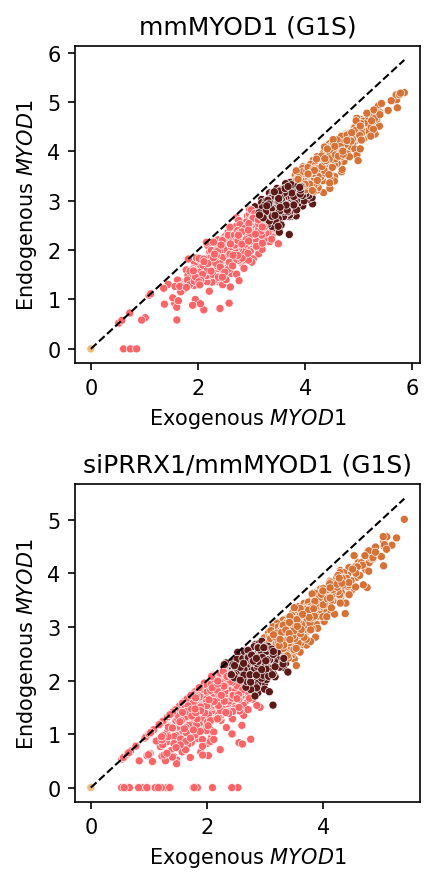

In [76]:
groups = adata.obs[['exp_phase_group']].copy()
groups = groups.reset_index(names='cell_id')
print(groups.shape)

tmp = pd.merge(df1, groups, how='left', on='cell_id')

tmp['exp_level'] = tmp['exp_phase_group'].str.split('_').str[-2].str.upper()
tmp['phase_group'] = tmp['exp_phase_group'].str.split('_').str[-1].str.upper()

print(tmp.shape)
tmp.head()

fig, axes = plt.subplots(2, 1, figsize=(3, 6), dpi=150)
axes = axes.flatten()

conds_to_plot = ['mmMYOD1', 'siPRRX1/mmMYOD1']
phase = 'G1S'

palette = [
    '#F1BB7B',
    '#FD6467',
    '#5B1A18',
    '#D67236',
]

for i, cond in enumerate(conds_to_plot):
    ax = axes[i]
    
    tmp1 = tmp[(tmp['pooled_condition'] == cond) & (tmp['phase_group'] == phase)].copy()
    print(f'{cond} {phase}: {len(tmp1)}')
    
    sns.scatterplot(
        tmp1,
        x='MYOD1_exo',
        y='MYOD1_endo',
        hue='exp_level',
        hue_order=['NE', 'LOW', 'MED', 'HIGH'],
        palette=palette,
        s=15,
        ax=ax,
        legend=False,
    )
    
    ax.set_title(f'{cond} ({phase})')
    ax.set_ylabel('Endogenous $MYOD1$')
    ax.set_xlabel('Exogenous $MYOD1$')
    
    # Identity line
    min_val = min(tmp1['MYOD1_exo'].min(), tmp1['MYOD1_endo'].min())
    max_val = max(tmp1['MYOD1_exo'].max(), tmp1['MYOD1_endo'].max())
    
    ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='black', lw=1)
    

plt.tight_layout()
plt.show()

In [12]:
# G1S
phase = 'G1S'

groups = [f'mmMYOD1_high_{phase}', f'mmMYOD1_low_{phase}', f'mmMYOD1_med_{phase}']

tmp = adata.obs[adata.obs['exp_phase_group'].isin(groups)]
print(tmp['exp_phase_group'].value_counts())

sc.tl.rank_genes_groups(
    adata,
    groupby='exp_phase_group',
    groups=groups,
    reference=f'Control_{phase}',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='myod_vs_ctrl_g1s',
)

exp_phase_group
mmMYOD1_high_G1S    609
mmMYOD1_med_G1S     550
mmMYOD1_low_G1S     504
Name: count, dtype: int64
ranking genes


... storing 'phase' as categorical
... storing 'exp_level_group' as categorical
... storing 'phase_grouped' as categorical
... storing 'exp_phase_group' as categorical


    finished (0:00:24)


In [79]:
# in HIGH group
deg_key = 'myod_vs_ctrl_g1s'

deg = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key=deg_key,
)

deg['reference_group'] = 'Control_G1S'
deg['direction'] = np.where(deg['logfoldchanges'] > 0, 'up', 'down')

print(deg.shape)
deg.head()

mdf = deg[deg['pvals_adj'] < 0.05].copy()
print(mdf.shape)
mdf.head()

(75384, 9)
(20129, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,mmMYOD1_high_G1S,MYOD1_endo,39.417999,35.391575,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
1,mmMYOD1_high_G1S,MYOD1_exo,39.417999,36.277603,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
2,mmMYOD1_high_G1S,MYOD1,39.288548,33.273232,0.000000e+00,0.000000e+00,0.996716,Control_G1S,up
3,mmMYOD1_high_G1S,MT-ND4,39.286720,3.184768,0.000000e+00,0.000000e+00,0.998358,Control_G1S,up
4,mmMYOD1_high_G1S,LINC-PINT,34.743896,3.124334,1.713625e-264,6.240575e-262,0.963875,Control_G1S,up


In [16]:
### HYB
phase = 'G1S'

groups = [f'siPRRX1/mmMYOD1_high_{phase}', f'siPRRX1/mmMYOD1_low_{phase}', f'siPRRX1/mmMYOD1_med_{phase}']

tmp = adata.obs[adata.obs['exp_phase_group'].isin(groups)]
print(tmp['exp_phase_group'].value_counts())

sc.tl.rank_genes_groups(
    adata,
    groupby='exp_phase_group',
    groups=groups,
    reference=f'Control_{phase}',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='hyb_vs_ctrl_g1s',
)

exp_phase_group
siPRRX1/mmMYOD1_high_G1S    774
siPRRX1/mmMYOD1_med_G1S     678
siPRRX1/mmMYOD1_low_G1S     641
mmMYOD1_NE_G1S                0
mmMYOD1_high_G1S              0
mmMYOD1_high_G2M              0
mmMYOD1_low_G1S               0
mmMYOD1_NE_G2M                0
Control_G1S                   0
Control_G2M                   0
mmMYOD1_med_G2M               0
mmMYOD1_med_G1S               0
mmMYOD1_low_G2M               0
siPRRX1/mmMYOD1_NE_G1S        0
siPRRX1/mmMYOD1_high_G2M      0
siPRRX1/mmMYOD1_NE_G2M        0
siPRRX1/mmMYOD1_low_G2M       0
siPRRX1/mmMYOD1_med_G2M       0
siPRRX1_NE_G1S                0
siPRRX1_NE_G2M                0
siPRRX1_high_G1S              0
siPRRX1_high_G2M              0
siPRRX1_low_G1S               0
siPRRX1_low_G2M               0
siPRRX1_med_G1S               0
siPRRX1_med_G2M               0
Name: count, dtype: int64
ranking genes
    finished (0:00:24)


In [80]:
# in HIGH group
deg_key = 'hyb_vs_ctrl_g1s'

deg = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key=deg_key,
)

deg['reference_group'] = 'Control_G1S'
deg['direction'] = np.where(deg['logfoldchanges'] > 0, 'up', 'down')

print(deg.shape)
deg.head()

hdf = deg[deg['pvals_adj'] < 0.05].copy()
print(hdf.shape)
hdf.head()

(75384, 9)
(20089, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,siPRRX1/mmMYOD1_high_G1S,MYOD1_endo,43.565788,34.349598,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
1,siPRRX1/mmMYOD1_high_G1S,MYOD1_exo,43.565788,35.113995,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
2,siPRRX1/mmMYOD1_high_G1S,MT-ND4,43.562412,2.997419,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
3,siPRRX1/mmMYOD1_high_G1S,MYOD1,42.721489,32.044655,0.000000e+00,0.000000e+00,0.980620,Control_G1S,up
4,siPRRX1/mmMYOD1_high_G1S,LINC-PINT,36.573940,2.692000,7.426061e-293,4.339583e-290,0.970284,Control_G1S,up


# Load DEG tables

In [4]:
# fpath = "../../tables/DEGs_MyodExpLevels_HYB_G1S.csv"

# hdf = pd.read_csv(fpath)
# print(hdf.shape)
# display(hdf.head())



# fpath = "../../tables/DEGs_MyodExpLevels_mmMYOD1_G1S.csv"

# mdf = pd.read_csv(fpath)
# print(mdf.shape)
# display(mdf.head())

(21850, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,siPRRX1/mmMYOD1_high_G1S,MYOD1_exo,47.505005,35.085710,0.0,0.0,1.000000,Control_G1S,up
1,siPRRX1/mmMYOD1_high_G1S,MYOD1_endo,47.505005,34.325275,0.0,0.0,1.000000,Control_G1S,up
2,siPRRX1/mmMYOD1_high_G1S,MT-ND4,47.501183,2.978337,0.0,0.0,1.000000,Control_G1S,up
3,siPRRX1/mmMYOD1_high_G1S,MYOD1,46.688595,32.032375,0.0,0.0,0.982814,Control_G1S,up
4,siPRRX1/mmMYOD1_high_G1S,LINC-PINT,38.898235,2.623778,0.0,0.0,0.963480,Control_G1S,up


(21381, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,mmMYOD1_high_G1S,MYOD1_exo,41.296528,36.265495,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
1,mmMYOD1_high_G1S,MYOD1_endo,41.296528,35.380703,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
2,mmMYOD1_high_G1S,MYOD1,41.172330,33.265804,0.000000e+00,0.000000e+00,0.996992,Control_G1S,up
3,mmMYOD1_high_G1S,MT-ND4,41.169952,3.180320,0.000000e+00,0.000000e+00,0.998496,Control_G1S,up
4,mmMYOD1_high_G1S,LINC-PINT,36.189045,3.098549,9.053250e-287,3.296958e-284,0.962406,Control_G1S,up


In [77]:
print(len(all_cc_genes))

293


In [81]:
hdf = hdf[hdf['names'].isin(all_cc_genes)]
print(hdf.shape)

mdf = mdf[mdf['names'].isin(all_cc_genes)]
print(mdf.shape)

(540, 9)
(463, 9)


In [107]:
df = pd.concat([mdf, hdf])
print(f'N unique DEGs: {df['names'].nunique()}')
print(df.shape)
df.head()

N unique DEGs: 233
(1003, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
11,mmMYOD1_high_G1S,GADD45A,29.386921,3.835200,8.069600e-190,1.379407e-187,0.866995,Control_G1S,up
50,mmMYOD1_high_G1S,GMNN,23.911446,2.720180,2.328514e-126,2.104708e-124,0.768473,Control_G1S,up
121,mmMYOD1_high_G1S,PLK2,19.568867,3.489337,2.849521e-85,1.539844e-83,0.604269,Control_G1S,up
170,mmMYOD1_high_G1S,NES,18.109802,2.473773,2.667038e-73,1.196738e-71,0.604269,Control_G1S,up
204,mmMYOD1_high_G1S,MYC,17.244390,3.097038,1.233044e-66,4.848815e-65,0.536946,Control_G1S,up


In [108]:
df = df[df['logfoldchanges'].abs() >= 0.5]

print(f'N unique DEGs: {df['names'].nunique()}')
print(df.shape)
df.head()

N unique DEGs: 213
(847, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
11,mmMYOD1_high_G1S,GADD45A,29.386921,3.835200,8.069600e-190,1.379407e-187,0.866995,Control_G1S,up
50,mmMYOD1_high_G1S,GMNN,23.911446,2.720180,2.328514e-126,2.104708e-124,0.768473,Control_G1S,up
121,mmMYOD1_high_G1S,PLK2,19.568867,3.489337,2.849521e-85,1.539844e-83,0.604269,Control_G1S,up
170,mmMYOD1_high_G1S,NES,18.109802,2.473773,2.667038e-73,1.196738e-71,0.604269,Control_G1S,up
204,mmMYOD1_high_G1S,MYC,17.244390,3.097038,1.233044e-66,4.848815e-65,0.536946,Control_G1S,up


In [109]:
df.groupby('group')['names'].nunique()

group
mmMYOD1_high_G1S            111
mmMYOD1_low_G1S             140
mmMYOD1_med_G1S             151
siPRRX1/mmMYOD1_high_G1S    128
siPRRX1/mmMYOD1_low_G1S     160
siPRRX1/mmMYOD1_med_G1S     157
Name: names, dtype: int64

In [112]:
# per group, how many DE cell cycle genes? How many UP/DOWN

counts = df.groupby(['group', 'direction'], observed=True).size().reset_index(name='count')
counts['count'] = counts.apply(lambda row: -row['count'] if row['direction'] == 'down' else row['count'], axis=1)
plot_df = counts.pivot(index='group', columns='direction', values='count').fillna(0)


vmax = plot_df.max().max()
vmin = plot_df.min().min()

# group = 'mmMYOD1'
group = 'siPRRX1/mmMYOD1'

if group == 'mmMYOD1':
    ## mmMYOD1
    plot_df = plot_df.head(3)
if group == 'siPRRX1/mmMYOD1':
    plot_df = plot_df.tail(3)


plot_df.index = plot_df.index.str.split('_').str[-2].str.upper() 

plot_df

direction,down,up
group,,
HIGH,-22,106
LOW,-7,153
MED,-9,148


direction,down,up
group,,
LOW,-7,153
MED,-9,148
HIGH,-22,106


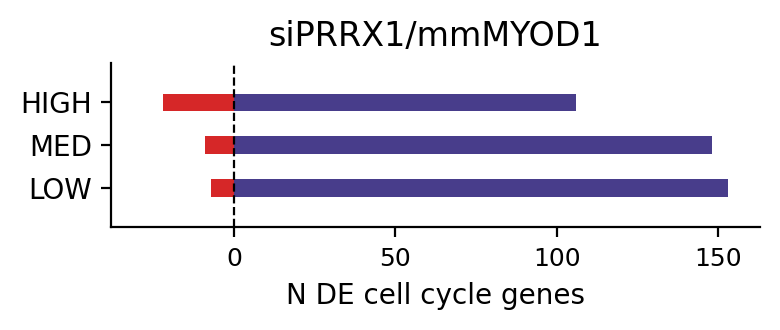

In [113]:
plot_order = ['LOW', 'MED', 'HIGH']
plot_df = plot_df.reindex(plot_order)
display(plot_df)

# plot
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 1.75
fig, ax = plt.subplots()

bar_width = 0.4

ax.barh(plot_df.index, plot_df['up'], color='darkslateblue', label='Up', height=bar_width)
ax.barh(plot_df.index, plot_df['down'], color='tab:red', label='Down', height=bar_width)

ax.axvline(0, color='k', linewidth=0.8, ls='--')

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(plot_order)
ax.margins(y=0.3)


ax.set_xlim([vmin-10, vmax+10])

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: int(abs(x))))
ax.tick_params(axis='x', labelsize=9)

ax.set_title(f'{group}')

ax.set_xlabel('N DE cell cycle genes')

sns.despine()
plt.tight_layout()
plt.show()

In [114]:
counts = df.groupby(['group', 'direction'], observed=True).size().reset_index(name='count')
counts['count'] = counts.apply(lambda row: -row['count'] if row['direction'] == 'down' else row['count'], axis=1)
plot_df = counts.pivot(index='group', columns='direction', values='count').fillna(0)

plot_df['total'] = -plot_df['down'] + plot_df['up']

total_cc_genes = len(all_cc_genes)
print(total_cc_genes)

plot_df['prop_of_all'] = plot_df['total'] / total_cc_genes

plot_df


293


direction,down,up,total,prop_of_all
group,,,,
mmMYOD1_high_G1S,-28,83,111,0.378840
mmMYOD1_low_G1S,-8,132,140,0.477816
mmMYOD1_med_G1S,-16,135,151,0.515358
siPRRX1/mmMYOD1_high_G1S,-22,106,128,0.436860
siPRRX1/mmMYOD1_low_G1S,-7,153,160,0.546075
siPRRX1/mmMYOD1_med_G1S,-9,148,157,0.535836


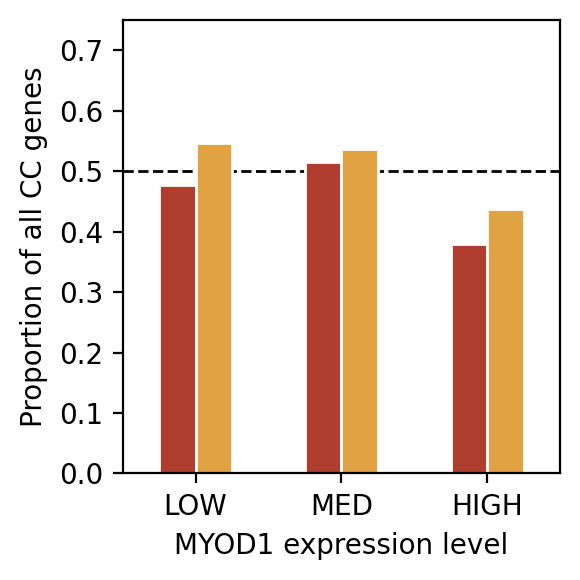

In [115]:
# Reset index for plotting
pdf = plot_df.reset_index()

pdf['condition'] = pdf['group'].str.split('_').str[0]
pdf['exp_level'] = pdf['group'].str.split('_').str[-2].str.upper()

pdf.head()


plt.figure(figsize=(3, 3), dpi=200)

colors = {'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A'}

sns.barplot(
    data=pdf,
    x='exp_level',
    y='prop_of_all',
    hue='condition',
    order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    width=0.5,
    ec='white',
)

plt.ylim([0.0, 0.75])

plt.axhline(y=0.5, ls='--', color='k', lw=1, zorder=0)

# plt.xticks(rotation=45, ha='right')
plt.ylabel('Proportion of all CC genes')
plt.xlabel('MYOD1 expression level')
plt.tight_layout()
plt.show()

In [116]:
N = len(all_cc_genes) # total number of cell cycle genes tested

tmp = plot_df.copy()
tmp = tmp.reset_index()

tmp['exp_level'] = tmp['group'].str.split('_').str[-2].str.upper()
tmp['condition'] = tmp['group'].str.split('_').str[-3]

for cond in tmp['condition'].unique():
    
    print(f'{cond}:')
    
    tmp1 = tmp[tmp['condition'] == cond]
    
    high = tmp1.loc[tmp1['exp_level'] == 'HIGH', 'prop_of_all'].values[0]
    med = tmp1.loc[tmp1['exp_level'] == 'MED', 'prop_of_all'].values[0]
    low = tmp1.loc[tmp1['exp_level'] == 'LOW', 'prop_of_all'].values[0]
    
    high_low_diff = low - high
    avg_drop = ((low - med) + (med - high)) / 2
    
    print(f'Δ LOW → HIGH = {high_low_diff:.4f}')
    print(f'Δ LOW → MED = {(low - med):.4f}')
    print(f'Δ MED → HIGH = {(med - high):.4f}')
    print(f'Per-step average drop (LOW → MED, MED → HIGH) = {avg_drop:.4f}\n')


mmMYOD1:
Δ LOW → HIGH = 0.0990
Δ LOW → MED = -0.0375
Δ MED → HIGH = 0.1365
Per-step average drop (LOW → MED, MED → HIGH) = 0.0495

siPRRX1/mmMYOD1:
Δ LOW → HIGH = 0.1092
Δ LOW → MED = 0.0102
Δ MED → HIGH = 0.0990
Per-step average drop (LOW → MED, MED → HIGH) = 0.0546



In [117]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [118]:
N = len(all_cc_genes) # total number of cell cycle genes tested

tmp = plot_df.copy()
tmp = tmp.reset_index()

tmp['exp_level'] = tmp['group'].str.split('_').str[-2].str.upper()
tmp['condition'] = tmp['group'].str.split('_').str[-3]

level_map = {'LOW': 0, 'MED': 1, 'HIGH': 2}

tmp['level_ord'] = tmp['exp_level'].map(level_map)

tmp['fail'] = N - tmp['total']

# Main-effects model: one overall monotonic trend + condition shift
m1 = smf.glm('prop_of_all ~ level_ord + C(condition)',
             data=tmp,
             family=sm.families.Binomial(),
             freq_weights=np.repeat(N, len(tmp))  # treat each row as N trials
            ).fit()

print(m1.summary())

# Quantifying number: odds ratio per one-step increase (LOW->MED or MED->HIGH)
beta = m1.params['level_ord']
se = m1.bse['level_ord']
OR = np.exp(beta)
CI = np.exp([beta - 1.96*se, beta + 1.96*se])
print("OR per MYOD1 level step:", OR, "95% CI:", CI)

                 Generalized Linear Model Regression Results                  
Dep. Variable:            prop_of_all   No. Observations:                    6
Model:                            GLM   Df Residuals:                     1755
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -790.48
Date:                Tue, 12 May 2026   Deviance:                       7.5984
Time:                        15:56:25   Pearson chi2:                     7.61
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9410
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [119]:
pred_grid = pd.DataFrame({
    'level_ord': [0,1,2]*2,
    'condition': ['mmMYOD1']*3 + ['siPRRX1/mmMYOD1']*3
})
pred = m1.get_prediction(pred_grid).summary_frame()
pred_grid['p_hat'] = pred['mean']
pred_grid['p_lo']  = pred['mean_ci_lower']
pred_grid['p_hi']  = pred['mean_ci_upper']
print(pred_grid)

   level_ord        condition     p_hat      p_lo      p_hi
0          0          mmMYOD1  0.509354  0.465587  0.552979
1          1          mmMYOD1  0.457027  0.424212  0.490220
2          2          mmMYOD1  0.405632  0.363745  0.448939
3          0  siPRRX1/mmMYOD1  0.558469  0.514742  0.601307
4          1  siPRRX1/mmMYOD1  0.506303  0.473152  0.539399
5          2  siPRRX1/mmMYOD1  0.454000  0.410905  0.497795


In [120]:
m2 = smf.glm('prop_of_all ~ level_ord * C(condition)',
             data=tmp,
             family=sm.families.Binomial(),
             freq_weights=np.repeat(N, len(tmp))
            ).fit()

# Likelihood ratio test: does interaction improve fit?
lr = 2*(m2.llf - m1.llf)
df_diff = m2.df_model - m1.df_model
from scipy.stats import chi2
p = chi2.sf(lr, df_diff)
print("LR test interaction p =", p)

LR test interaction p = 0.8699842792914102


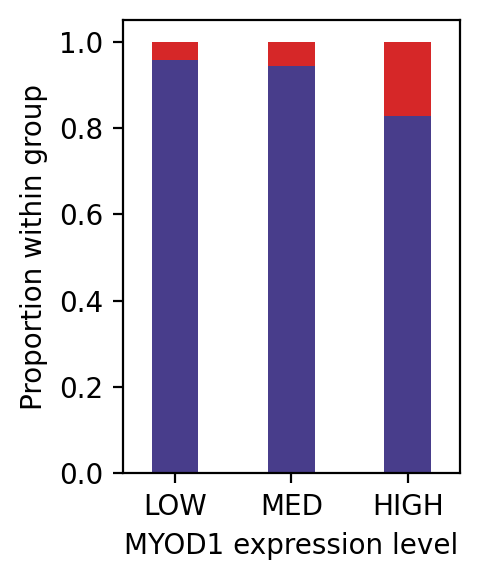

In [122]:
prop_df = plot_df.copy()

prop_df['up_prop'] = prop_df['up'] / prop_df['total']
prop_df['down_prop'] = (-prop_df['down']) / prop_df['total']  # flip sign back

# Keep only what we need
prop_df = prop_df[['up_prop', 'down_prop']]

group = 'siPRRX1/mmMYOD1'
# group = 'mmMYOD1'

if group == 'mmMYOD1':
    ## mmMYOD1
    prop_df = prop_df.head(3)
if group == 'siPRRX1/mmMYOD1':
    prop_df = prop_df.tail(3)


prop_df.index = prop_df.index.str.split('_').str[-2].str.upper() 
prop_df = prop_df.reindex(['LOW', 'MED', 'HIGH'])

plt.figure(figsize=(2.5, 3), dpi=200)

palette = ['darkslateblue', 'tab:red']

# Plot stacked bars
prop_df.plot(
    kind='bar',
    stacked=True,
    ax=plt.gca(),
    legend=False,
    color=palette,
    width=0.4,
)

plt.xticks(rotation=0)
plt.ylabel('Proportion within group')
plt.xlabel('MYOD1 expression level')


plt.tight_layout()
plt.show()

In [33]:
### within each group, how correlated are logFCs for the same genes

df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
11,mmMYOD1_high_G1S,GADD45A,29.386921,3.835200,8.069600e-190,1.379407e-187,0.866995,Control_G1S,up
50,mmMYOD1_high_G1S,GMNN,23.911446,2.720180,2.328514e-126,2.104708e-124,0.768473,Control_G1S,up
121,mmMYOD1_high_G1S,PLK2,19.568867,3.489337,2.849521e-85,1.539844e-83,0.604269,Control_G1S,up
170,mmMYOD1_high_G1S,NES,18.109802,2.473773,2.667038e-73,1.196738e-71,0.604269,Control_G1S,up
204,mmMYOD1_high_G1S,MYC,17.244390,3.097038,1.233044e-66,4.848815e-65,0.536946,Control_G1S,up


In [123]:
df['condition'] = df['group'].str.split('_').str[0]
df['exp_level'] = df['group'].str.split('_').str[-2].str.upper()

df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level
11,mmMYOD1_high_G1S,GADD45A,29.386921,3.835200,8.069600e-190,1.379407e-187,0.866995,Control_G1S,up,mmMYOD1,HIGH
50,mmMYOD1_high_G1S,GMNN,23.911446,2.720180,2.328514e-126,2.104708e-124,0.768473,Control_G1S,up,mmMYOD1,HIGH
121,mmMYOD1_high_G1S,PLK2,19.568867,3.489337,2.849521e-85,1.539844e-83,0.604269,Control_G1S,up,mmMYOD1,HIGH
170,mmMYOD1_high_G1S,NES,18.109802,2.473773,2.667038e-73,1.196738e-71,0.604269,Control_G1S,up,mmMYOD1,HIGH
204,mmMYOD1_high_G1S,MYC,17.244390,3.097038,1.233044e-66,4.848815e-65,0.536946,Control_G1S,up,mmMYOD1,HIGH


In [124]:
from scipy.stats import pearsonr, spearmanr

In [145]:
# cond = 'mmMYOD1'
cond = 'siPRRX1/mmMYOD1'

tmp = df[df['condition'] == cond].copy()

high = tmp[tmp['exp_level'] == 'HIGH']['names'].unique()
med = tmp[tmp['exp_level'] == 'MED']['names'].unique()
low = tmp[tmp['exp_level'] == 'LOW']['names'].unique()

shared_genes = list(set(high) & set(med) & set(low))
print(len(shared_genes))


tmp = tmp[tmp['names'].isin(shared_genes)]

wdf = (
    tmp[["names", "exp_level", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "exp_level"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="exp_level", values="logfoldchanges")
      .rename(columns={
          'LOW':  "logFC_low",
          'MED':  "logFC_med",
          'HIGH': "logFC_high",
      })
)

print(wdf.shape)
wdf.head() 

98
(98, 3)


exp_level,logFC_high,logFC_low,logFC_med
names,,,
ABL1,1.329288,0.980219,1.068060
ANAPC1,1.677289,1.656866,1.606906
ANAPC10,0.706502,0.700879,0.775609
ANAPC7,1.391006,1.250532,1.211169
ANLN,1.421448,2.323539,1.984894


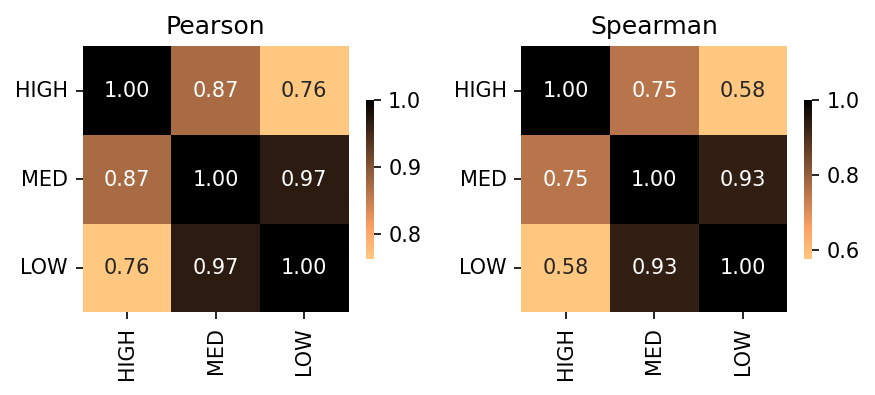

In [146]:
corr_p = wdf.corr(method='pearson')
corr_s = wdf.corr(method='spearman')

label_map = {
    'logFC_high': 'HIGH',
    'logFC_med': 'MED',
    'logFC_low': 'LOW',
}

row_order = ['logFC_high', 'logFC_med', 'logFC_low']
corr_p = corr_p.loc[row_order, row_order]
corr_s = corr_s.loc[row_order, row_order]

corr_p = corr_p.rename(index=label_map, columns=label_map)
corr_s = corr_s.rename(index=label_map, columns=label_map)

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), dpi=150)

cbar_kws = {'shrink': 0.6}
cmap = "copper_r"

sns.heatmap(corr_p, annot=True, fmt=".2f", cmap=cmap, cbar=True, square=True, cbar_kws=cbar_kws, ax=axes[0])
axes[0].set_title('Pearson')
sns.heatmap(corr_s, annot=True, fmt=".2f", cmap=cmap, cbar=True, square=True, cbar_kws=cbar_kws, ax=axes[1])
axes[1].set_title('Spearman')

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel('')
    ax.set_ylabel('')


plt.tight_layout()
plt.show()

In [20]:
df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level
11,mmMYOD1_high_G1S,GADD45A,30.761957,3.718991,8.461841e-208,1.446457e-205,0.872180,Control_G1S,up,mmMYOD1,HIGH
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up,mmMYOD1,HIGH
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up,mmMYOD1,HIGH
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up,mmMYOD1,HIGH
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up,mmMYOD1,HIGH


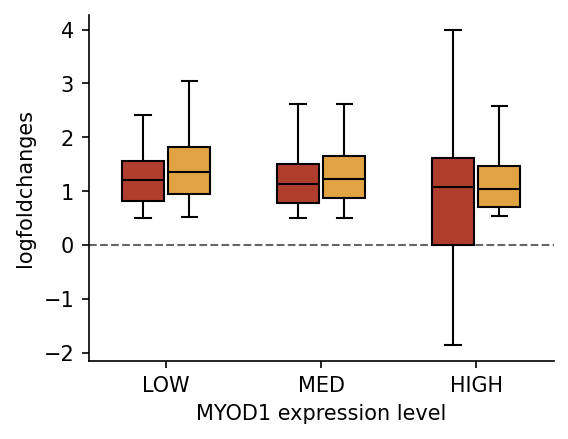

In [147]:
plt.figure(figsize=(4, 3), dpi=150)

colors = {'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A'}

sns.boxplot(
    df,
    x='exp_level',
    y='logfoldchanges',
    hue='condition',
    order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('MYOD1 expression level')

plt.axhline(y=0, ls='--', color='k', lw=1, alpha=0.6, zorder=0)

sns.despine()
plt.show()

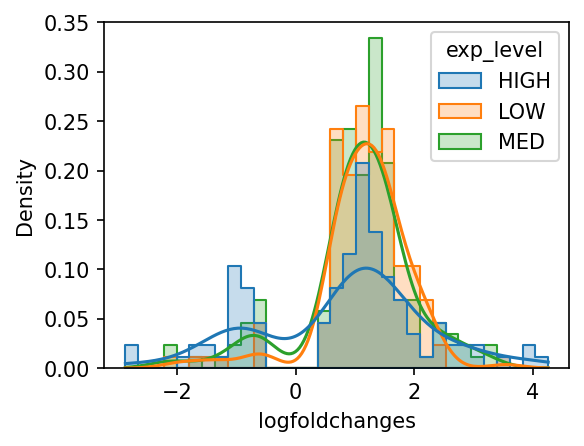

In [40]:
plt.figure(figsize=(4, 3), dpi=150)

cond = 'mmMYOD1'

tmp = df[df['condition'] == cond]

sns.histplot(
    tmp,
    x='logfoldchanges',
    kde=True,
    hue='exp_level',
    element='step',
    stat='density',
)

plt.show()

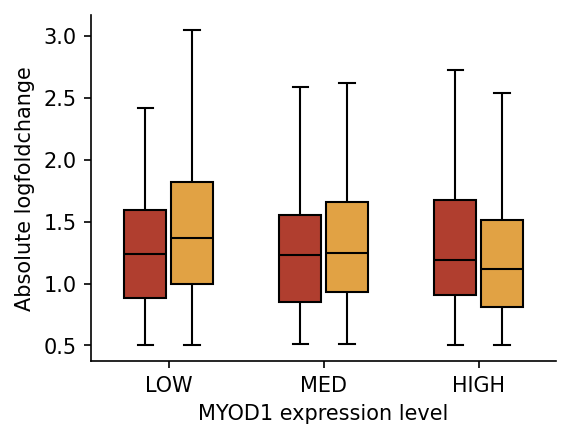

In [148]:
df['abs_lfc'] = df['logfoldchanges'].apply(abs)

plt.figure(figsize=(4, 3), dpi=150)

colors = {'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A'}

sns.boxplot(
    df,
    x='exp_level',
    y='abs_lfc',
    hue='condition',
    order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('MYOD1 expression level')
plt.ylabel('Absolute logfoldchange')
# plt.axhline(y=0, ls='--', color='k', lw=1, alpha=0.6, zorder=0)

sns.despine()
plt.show()

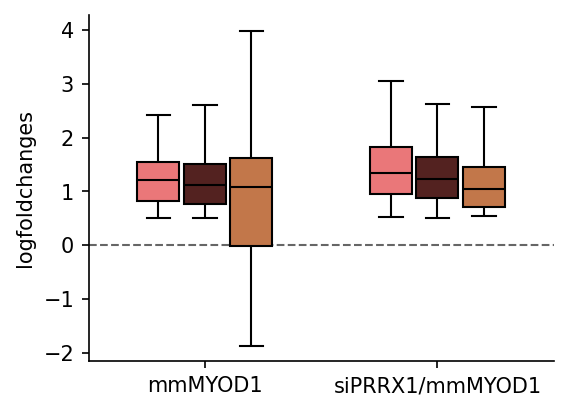

In [149]:
plt.figure(figsize=(4, 3), dpi=150)

colors = {
    'LOW': '#FD6467',
    'MED': '#5B1A18',
    'HIGH': '#D67236',
}

sns.boxplot(
    df,
    x='condition',
    y='logfoldchanges',
    hue='exp_level',
    hue_order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('')

plt.axhline(y=0, ls='--', color='k', lw=1, alpha=0.6, zorder=0)

sns.despine()
plt.show()

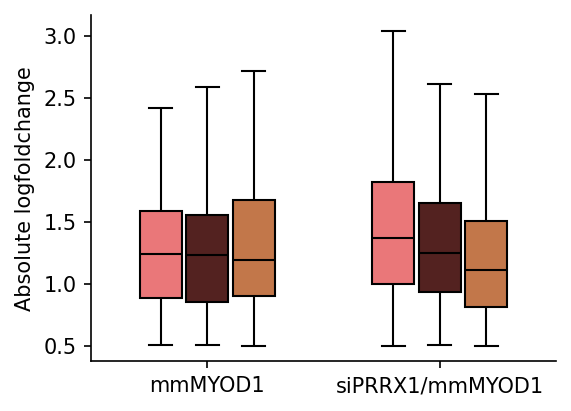

In [150]:
plt.figure(figsize=(4, 3), dpi=150)

colors = {
    'LOW': '#FD6467',
    'MED': '#5B1A18',
    'HIGH': '#D67236',
}

sns.boxplot(
    df,
    x='condition',
    y='abs_lfc',
    hue='exp_level',
    hue_order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('')
plt.ylabel('Absolute logfoldchange')

sns.despine()
plt.show()

In [39]:
df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up,mmMYOD1,HIGH,2.295428
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up,mmMYOD1,HIGH,3.490016
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up,mmMYOD1,HIGH,2.351126
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up,mmMYOD1,HIGH,2.979373
399,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up,mmMYOD1,HIGH,1.147300


In [169]:
# group_key = 'mmMYOD1'
group_key = 'siPRRX1/mmMYOD1'

groups_keep = [f'{group_key}_low_G1S', f'{group_key}_high_G1S']

direction = 'down'

tmp = df[df['direction'] == direction].copy()


wdf = (
    tmp.loc[tmp["group"].isin(groups_keep), ["names", "group", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "group"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="group", values="logfoldchanges")
      .rename(columns={
          f'{group_key}_low_G1S':  "logFC_low",
          f'{group_key}_high_G1S': "logFC_high",
      })
)

if direction == 'down':
    wdf = wdf.abs()

print(wdf.shape)
wdf.head()

(24, 2)


group,logFC_high,logFC_low
names,,
ANAPC11,0.802971,NaN
ANAPC5,0.816815,NaN
APP,2.165673,1.761685
BCAT1,0.569696,NaN
CALM2,0.509815,NaN


N shared downregulated genes: 5
(5, 3)


group,logFC_high,logFC_low,delta_high_low
names,,,
APP,2.165673,1.761685,0.403989
EIF4EBP1,1.796843,1.234505,0.562338
ITGB1,1.995550,1.121426,0.874124
PBX1,1.410150,1.558393,-0.148242
TGFB1,0.913492,0.583343,0.330149


% stronger in HIGH: 80.00%



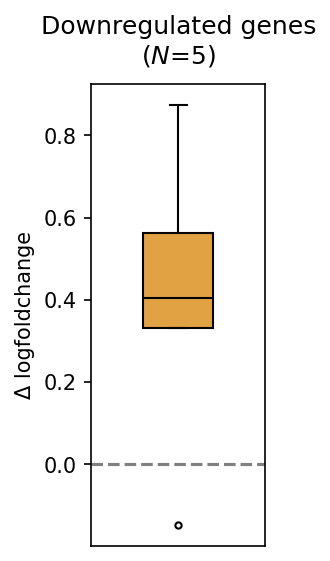

In [170]:
wdf1 = wdf.dropna(subset=['logFC_low', 'logFC_high']).copy()
print(f'N shared {direction}regulated genes: {len(wdf1)}')

wdf1['delta_high_low'] = wdf1['logFC_high'] - wdf1['logFC_low']

print(wdf1.shape)
display(wdf1.head())

if group_key == 'mmMYOD1':
    color = '#C52E19'
elif group_key == 'siPRRX1/mmMYOD1':
    color = '#FBA72A'
else:
    color='white'

    
wdf2 = wdf1.copy()
wdf2['pos_delta'] = wdf2['delta_high_low'] > 0
print(f"% stronger in HIGH: {wdf2['pos_delta'].sum()/len(wdf2)*100:.2f}%\n")

plt.figure(figsize=(1.5, 4), dpi=150)

sns.boxplot(
    wdf1,
    y='delta_high_low',
    width=0.4,
    color=color,
    linecolor='k',
    fliersize=3,
    capwidths=0.1,
    # showfliers=False,
)

plt.ylabel("Δ logfoldchange")
plt.gca().tick_params(axis='x', bottom=False)

plt.axhline(y=0, ls='--', color='gray', zorder=0)

if direction == 'up':
    plt.title(f"Upregulated genes\n($N$={len(wdf1)})", pad=10)
    
if direction == 'down':
    plt.title(f"Downregulated genes\n($N$={len(wdf1)})", pad=10)
    
plt.show()

In [ ]:
### upset plots for matches/mismatches / unique 

In [176]:
# group_key = 'siPRRX1/mmMYOD1'
group_key = 'mmMYOD1'

groups_keep = [f'{group_key}_low_G1S', f'{group_key}_high_G1S']

kdf = df[df['group'].isin(groups_keep)].copy()
print(kdf.shape)


# Step 1: build a per-gene summary of directions across groups
gene_summary = (
    kdf.groupby('names')
      .agg(
          n_groups=('group', 'nunique'),
          n_directions=('direction', lambda x: x.nunique()),
          direction_set=('direction', lambda x: set(x))
      )
      .reset_index()
)

# Step 2: define logic for consistency
def classify(row):
    if row['n_groups'] == 1:
        return 'unique_to_group'
    elif row['n_directions'] == 1:
        return 'match'
    else:
        return 'mismatch'

gene_summary['direction_consistency'] = gene_summary.apply(classify, axis=1)

# Step 3: map back to original dataframe
kdf = kdf.merge(
    gene_summary[['names', 'direction_consistency']],
    on='names',
    how='left'
)

kdf.head()

(251, 12)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc,direction_consistency
0,mmMYOD1_high_G1S,GADD45A,29.386921,3.835200,8.069600e-190,1.379407e-187,0.866995,Control_G1S,up,mmMYOD1,HIGH,3.835200,match
1,mmMYOD1_high_G1S,GMNN,23.911446,2.720180,2.328514e-126,2.104708e-124,0.768473,Control_G1S,up,mmMYOD1,HIGH,2.720180,match
2,mmMYOD1_high_G1S,PLK2,19.568867,3.489337,2.849521e-85,1.539844e-83,0.604269,Control_G1S,up,mmMYOD1,HIGH,3.489337,match
3,mmMYOD1_high_G1S,NES,18.109802,2.473773,2.667038e-73,1.196738e-71,0.604269,Control_G1S,up,mmMYOD1,HIGH,2.473773,match
4,mmMYOD1_high_G1S,MYC,17.244390,3.097038,1.233044e-66,4.848815e-65,0.536946,Control_G1S,up,mmMYOD1,HIGH,3.097038,match


In [177]:
print(kdf['names'].nunique())

print("\n", kdf.groupby('group')['names'].nunique())

print("\n", kdf.groupby(['group', 'direction'])['names'].nunique())

print("\n", kdf.groupby('group')['direction_consistency'].value_counts())

176

 group
mmMYOD1_high_G1S    111
mmMYOD1_low_G1S     140
Name: names, dtype: int64

 group             direction
mmMYOD1_high_G1S  down          28
                  up            83
mmMYOD1_low_G1S   down           8
                  up           132
Name: names, dtype: int64

 group             direction_consistency
mmMYOD1_high_G1S  match                    75
                  unique_to_group          36
mmMYOD1_low_G1S   match                    75
                  unique_to_group          65
Name: count, dtype: int64


In [178]:
counts = kdf.groupby(['group', 'direction_consistency'], observed=True).size().reset_index(name='count')
plot_df = counts.pivot(index='group', columns='direction_consistency', values='count').fillna(0)

plot_df.index = plot_df.index.str.split('_').str[-2].str.upper() 

plot_df

direction_consistency,match,unique_to_group
group,,
HIGH,75,36
LOW,75,65


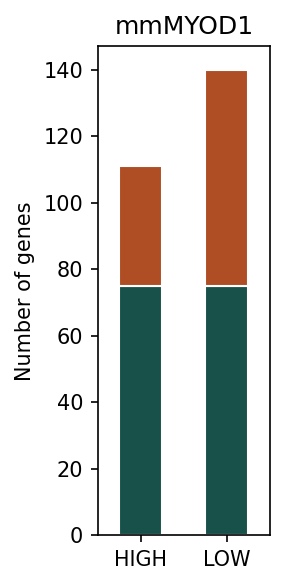

In [179]:
fig, ax = plt.subplots(figsize=(2, 4), dpi=150)

colors = {
    'match': '#175149',
    'mismatch': '#54D8B1',
    'unique_to_group': '#AF4E24',
}

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    width=0.5,
    ax=ax,
    color=colors,
    ec='white',
)

ax.set_ylabel('Number of genes')
ax.set_xlabel('')
ax.set_title(f'{group_key}')
ax.tick_params(axis='x', rotation=0)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

,siPRRX1/mmMYOD1_high_G1S,siPRRX1/mmMYOD1_low_G1S
MCM6,-0.694308,0.580596


(1, 2)


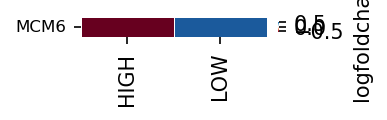

In [175]:
mdf = kdf[kdf['direction_consistency'] == 'mismatch'].copy()

mdf.head()

mdf = mdf.pivot(index='names', columns='group', values="logfoldchanges")
mdf.index.name = None
mdf.columns.name = None
display(mdf.head())
print(mdf.shape)

vmin = (mdf.min()).min()
vmax = (mdf.max()).max()

# plt.figure(figsize=(2, 3.5), dpi=150)
plt.figure(figsize=(2, len(mdf)*0.18), dpi=150)
ax = sns.heatmap(
    mdf,
    # cmap=custom_cmap,
    cmap="RdBu",
    linewidths=0.35,
    linecolor="white",
    # cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    vmin=vmin,
    vmax=vmax,
    center=0,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(["HIGH", "LOW"], rotation=90)

ax.set_yticks([i + 0.5 for i in range(len(mdf))])
ax.set_yticklabels(mdf.index.to_list(), fontsize=8, va='center')


plt.tight_layout()
plt.show()

In [184]:
dir_key = 'med'

groups_keep = [f'mmMYOD1_{dir_key}_G1S', f'siPRRX1/mmMYOD1_{dir_key}_G1S']

kdf = df[df['group'].isin(groups_keep)].copy()
print(kdf.shape)


# Step 1: build a per-gene summary of directions across groups
gene_summary = (
    kdf.groupby('names')
      .agg(
          n_groups=('group', 'nunique'),
          n_directions=('direction', lambda x: x.nunique()),
          direction_set=('direction', lambda x: set(x))
      )
      .reset_index()
)

# Step 2: define logic for consistency
def classify(row):
    if row['n_groups'] == 1:
        return 'unique_to_group'
    elif row['n_directions'] == 1:
        return 'match'
    else:
        return 'mismatch'

gene_summary['direction_consistency'] = gene_summary.apply(classify, axis=1)

# Step 3: map back to original dataframe
kdf = kdf.merge(
    gene_summary[['names', 'direction_consistency']],
    on='names',
    how='left'
)

display(kdf.head())


print(kdf['names'].nunique())

print("\n", kdf.groupby('group')['names'].nunique())

print("\n", kdf.groupby(['group', 'direction'])['names'].nunique())

print("\n", kdf.groupby('group')['direction_consistency'].value_counts())

(308, 12)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc,direction_consistency
0,mmMYOD1_med_G1S,GMNN,28.870295,3.202431,2.818801e-183,8.637907e-181,0.894545,Control_G1S,up,mmMYOD1,MED,3.202431,match
1,mmMYOD1_med_G1S,GADD45A,24.800114,3.225195,8.939563e-136,1.559954e-133,0.845455,Control_G1S,up,mmMYOD1,MED,3.225195,match
2,mmMYOD1_med_G1S,NES,21.430935,2.586268,6.878500e-102,7.965112e-100,0.714545,Control_G1S,up,mmMYOD1,MED,2.586268,match
3,mmMYOD1_med_G1S,CCND1,17.289200,1.163202,5.673378e-67,3.771445e-65,0.914545,Control_G1S,up,mmMYOD1,MED,1.163202,match
4,mmMYOD1_med_G1S,NASP,15.806744,1.241419,2.795484e-56,1.466491e-54,0.860000,Control_G1S,up,mmMYOD1,MED,1.241419,match


185

 group
mmMYOD1_med_G1S            151
siPRRX1/mmMYOD1_med_G1S    157
Name: names, dtype: int64

 group                    direction
mmMYOD1_med_G1S          down          16
                         up           135
siPRRX1/mmMYOD1_med_G1S  down           9
                         up           148
Name: names, dtype: int64

 group                    direction_consistency
mmMYOD1_med_G1S          match                    123
                         unique_to_group           28
siPRRX1/mmMYOD1_med_G1S  match                    123
                         unique_to_group           34
Name: count, dtype: int64


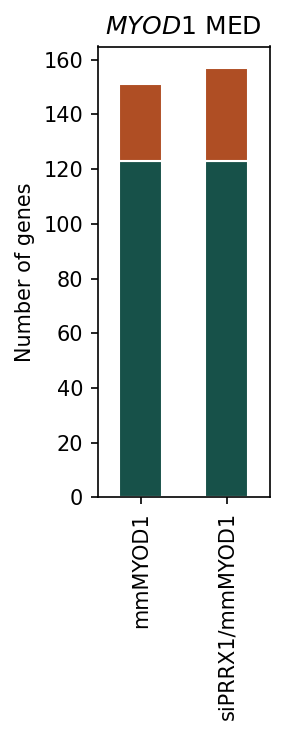

In [185]:
counts = kdf.groupby(['group', 'direction_consistency'], observed=True).size().reset_index(name='count')
plot_df = counts.pivot(index='group', columns='direction_consistency', values='count').fillna(0)

plot_df.index = plot_df.index.str.split('_').str[-3]

plot_df

fig, ax = plt.subplots(figsize=(2, 5), dpi=150)

colors = {
    'match': '#175149',
    'mismatch': '#54D8B1',
    'unique_to_group': '#AF4E24',
}

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    width=0.5,
    ax=ax,
    color=colors,
    ec='white',
)

ax.set_ylabel('Number of genes')
ax.set_xlabel('')
ax.set_title(f'$MYOD1$ {dir_key.upper()}')
ax.tick_params(axis='x', rotation=90)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

,mmMYOD1_high_G1S,siPRRX1/mmMYOD1_high_G1S
BIRC5,-0.588815,0.621688
DLGAP5,-1.016875,0.626647


(2, 2)


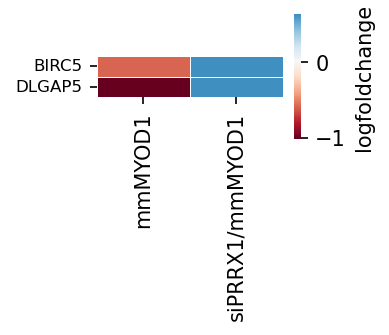

In [40]:
mdf = kdf[kdf['direction_consistency'] == 'mismatch'].copy()

mdf.head()

mdf = mdf.pivot(index='names', columns='group', values="logfoldchanges")
mdf.index.name = None
mdf.columns.name = None
display(mdf.head())
print(mdf.shape)

vmin = (mdf.min()).min()
vmax = (mdf.max()).max()

# plt.figure(figsize=(2, 3.5), dpi=150)
plt.figure(figsize=(2, len(mdf)*0.18), dpi=150)
ax = sns.heatmap(
    mdf,
    # cmap=custom_cmap,
    cmap="RdBu",
    linewidths=0.35,
    linecolor="white",
    # cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    cbar_kws={"label": "logfoldchange", 'shrink': 3},
    vmin=vmin,
    vmax=vmax,
    center=0,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(["mmMYOD1", "siPRRX1/mmMYOD1"], rotation=90)

ax.set_yticks([i + 0.5 for i in range(len(mdf))])
ax.set_yticklabels(mdf.index.to_list(), fontsize=8, va='center', rotation=0)


plt.tight_layout()
plt.show()

# Stats

In [151]:
print(df.shape)
df.head()

(847, 12)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc
11,mmMYOD1_high_G1S,GADD45A,29.386921,3.835200,8.069600e-190,1.379407e-187,0.866995,Control_G1S,up,mmMYOD1,HIGH,3.835200
50,mmMYOD1_high_G1S,GMNN,23.911446,2.720180,2.328514e-126,2.104708e-124,0.768473,Control_G1S,up,mmMYOD1,HIGH,2.720180
121,mmMYOD1_high_G1S,PLK2,19.568867,3.489337,2.849521e-85,1.539844e-83,0.604269,Control_G1S,up,mmMYOD1,HIGH,3.489337
170,mmMYOD1_high_G1S,NES,18.109802,2.473773,2.667038e-73,1.196738e-71,0.604269,Control_G1S,up,mmMYOD1,HIGH,2.473773
204,mmMYOD1_high_G1S,MYC,17.244390,3.097038,1.233044e-66,4.848815e-65,0.536946,Control_G1S,up,mmMYOD1,HIGH,3.097038


In [152]:
from scipy import stats
from itertools import combinations
from scipy.stats import shapiro, levene

In [153]:
# test normality, test homogeneity of variance

def normality_check(df, alpha=0.05, lfc_col='logfoldchanges', group_col='exp_level'):
    
    exp_levels = df[group_col].unique()
    
    for level in exp_levels:
        
        lfc = df[df[group_col] == level][lfc_col]
        
        stat1, p1 = stats.shapiro(lfc) # Shapiro-Wilk test
        stat2, p2 = stats.normaltest(lfc) # D’Agostino and Pearson’s test
        
        if p1 < alpha:
            sig1 = 'SIGNIFICANT (data is NOT normal)'
        else:
            sig1 = 'NOT SIGNIFICANT (data is normal)'
            
        if p2 < alpha:
            sig2 = 'SIGNIFICANT (data is NOT normal)'
        else:
            sig2 = 'NOT SIGNIFICANT (data is normal)'
        
        print(f'{level}:\tShapiro-Wilk p-val = {p1:.4e} {sig1},\tD’Agostino and Pearson’s p-val = {p2:.4e} {sig2}')

In [154]:
### mmMYOD1
tmp1 = df[df['condition'] == 'mmMYOD1'].copy()
print(tmp1.shape)

print('\n-------------- mmMYOD1 (raw logFC) --------------')
# raw logFC vals
normality_check(tmp1)

print('\n-------------- mmMYOD1 (absolute logFC) --------------')
# raw logFC vals
normality_check(tmp1, lfc_col='abs_lfc')



### siPRRX1/mmMYOD1
tmp2 = df[df['condition'] == 'siPRRX1/mmMYOD1'].copy()
print(tmp2.shape)

print('\n-------------- siPRRX1/mmMYOD1 (raw logFC) --------------')
# raw logFC vals
normality_check(tmp2)

print('\n-------------- siPRRX1/mmMYOD1 (absolute logFC) --------------')
# raw logFC vals
normality_check(tmp2, lfc_col='abs_lfc')

(402, 12)

-------------- mmMYOD1 (raw logFC) --------------
HIGH:	Shapiro-Wilk p-val = 1.0158e-03 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 4.0813e-01 NOT SIGNIFICANT (data is normal)
LOW:	Shapiro-Wilk p-val = 3.1022e-09 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 1.7047e-11 SIGNIFICANT (data is NOT normal)
MED:	Shapiro-Wilk p-val = 1.8891e-08 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 3.8855e-07 SIGNIFICANT (data is NOT normal)

-------------- mmMYOD1 (absolute logFC) --------------
HIGH:	Shapiro-Wilk p-val = 3.4423e-09 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 8.2497e-09 SIGNIFICANT (data is NOT normal)
LOW:	Shapiro-Wilk p-val = 6.4167e-05 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 3.7720e-05 SIGNIFICANT (data is NOT normal)
MED:	Shapiro-Wilk p-val = 2.5051e-08 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 1.2467e-07 SIGNIFICANT (data is NOT n

In [186]:
def manual_step_a(df, lfc_col='logfoldchanges', group_col='exp_level'):
    groups = df[group_col].unique()
    group_data = [df[df[group_col] == g][lfc_col] for g in groups]
    
    l_stat, l_p = stats.levene(*group_data)
    if l_p < 0.05:
        sig = 'SIGNIFICANT (unequal variances)'
    else:
        sig = 'NOT SIGNIFICANT (equal variances)'
    
    print(f"Levene's p-val: {l_p:.4e} {sig}")
    
    
    # 1. Global Test
    h_stat, p_global = stats.kruskal(*group_data)
    if p_global < 0.05:
        sig1 = 'SIGNIFICANT'
    else:
        sig1 = 'NOT SIGNIFICANT'
    
    print(f"Global Kruskal-Wallis p-value: {p_global:.4e} {sig1}\n") ### are any of the 3 groups (exp_levels) different?
    
    if p_global < 0.05:
        print("--- Pairwise Mann-Whitney U Tests (with Bonferroni) ---") ### comparing the "rank" (median) between 2 specific groups
        pairs = list(combinations(groups, 2))
        num_comparisons = len(pairs)
        
        for g1, g2 in pairs:
            d1 = df[df[group_col] == g1][lfc_col]
            d2 = df[df[group_col] == g2][lfc_col]
            
            # stat, p_unadj = stats.mannwhitneyu(d1, d2, alternative='two-sided')
            stat, p_unadj = stats.mannwhitneyu(d1, d2, alternative='less')
            
            # Manual Bonferroni Correction
            p_adj = min(p_unadj * num_comparisons, 1.0)
            
            print(f"{g1} vs {g2}: p-unadj={p_unadj:.4e}, p-adj={p_adj:.4e}")

In [187]:
### within condition (diffs between LOW/MED/HIGH)
print("Testing for differences between MYOD1 expression levels within each condition...\n")


### mmMYOD1
print("------------ mmMYOD1 ------------")
print("Raw logfoldchanges:")
manual_step_a(tmp1)
print("Absolute logfoldchanges:")
manual_step_a(tmp1, lfc_col='abs_lfc')


### siPRRX1mmMYOD1
print("\n------------ siPRRX1/mmMYOD1 ------------")
print("Raw logfoldchanges:")
manual_step_a(tmp2)
print("\n")
print("Absolute logfoldchanges:")
manual_step_a(tmp2, lfc_col='abs_lfc')

Testing for differences between MYOD1 expression levels within each condition...

------------ mmMYOD1 ------------
Raw logfoldchanges:
Levene's p-val: 2.1569e-07 SIGNIFICANT (unequal variances)
Global Kruskal-Wallis p-value: 1.7155e-01 NOT SIGNIFICANT

Absolute logfoldchanges:
Levene's p-val: 3.6188e-02 SIGNIFICANT (unequal variances)
Global Kruskal-Wallis p-value: 7.1262e-01 NOT SIGNIFICANT


------------ siPRRX1/mmMYOD1 ------------
Raw logfoldchanges:
Levene's p-val: 1.7140e-02 SIGNIFICANT (unequal variances)
Global Kruskal-Wallis p-value: 1.7543e-03 SIGNIFICANT

--- Pairwise Mann-Whitney U Tests (with Bonferroni) ---
HIGH vs LOW: p-unadj=2.8392e-04, p-adj=8.5176e-04
HIGH vs MED: p-unadj=1.1669e-02, p-adj=3.5008e-02
LOW vs MED: p-unadj=9.3941e-01, p-adj=1.0000e+00


Absolute logfoldchanges:
Levene's p-val: 5.6953e-01 NOT SIGNIFICANT (equal variances)
Global Kruskal-Wallis p-value: 1.2254e-02 SIGNIFICANT

--- Pairwise Mann-Whitney U Tests (with Bonferroni) ---
HIGH vs LOW: p-unadj=2

In [157]:
high_lfc = tmp1[tmp1['exp_level'] == 'HIGH']['logfoldchanges']
med_lfc = tmp1[tmp1['exp_level'] == 'MED']['logfoldchanges']
low_lfc = tmp1[tmp1['exp_level'] == 'LOW']['logfoldchanges']

# Testing the raw LFC distributions
# This detects differences in shape, variance, and median simultaneously
ad_stat, critical_values, p_val = stats.anderson_ksamp([high_lfc, med_lfc, low_lfc])
print(f"Anderson-Darling p-value: {p_val:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Anderson-Darling p-value: 6.2151e-03
Levene's test for variance p-value: 2.1569e-07


In [158]:
high_lfc = tmp1[tmp1['exp_level'] == 'HIGH']['abs_lfc']
med_lfc = tmp1[tmp1['exp_level'] == 'MED']['abs_lfc']
low_lfc = tmp1[tmp1['exp_level'] == 'LOW']['abs_lfc']

stat, p_magnitude = stats.kruskal(high_lfc, med_lfc, low_lfc)
print(f"Magnitude (Absolute LFC) p-value: {p_magnitude:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Magnitude (Absolute LFC) p-value: 7.1262e-01
Levene's test for variance p-value: 3.6188e-02


In [159]:
high_lfc = tmp2[tmp2['exp_level'] == 'HIGH']['logfoldchanges']
med_lfc = tmp2[tmp2['exp_level'] == 'MED']['logfoldchanges']
low_lfc = tmp2[tmp2['exp_level'] == 'LOW']['logfoldchanges']

# Testing the raw LFC distributions
# This detects differences in shape, variance, and median simultaneously
ad_stat, critical_values, p_val = stats.anderson_ksamp([high_lfc, med_lfc, low_lfc])
print(f"Anderson-Darling p-value: {p_val:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Anderson-Darling p-value: 1.4567e-03
Levene's test for variance p-value: 1.7140e-02


In [160]:
high_lfc = tmp2[tmp2['exp_level'] == 'HIGH']['abs_lfc']
med_lfc = tmp2[tmp2['exp_level'] == 'MED']['abs_lfc']
low_lfc = tmp2[tmp2['exp_level'] == 'LOW']['abs_lfc']

stat, p_magnitude = stats.kruskal(high_lfc, med_lfc, low_lfc)
print(f"Magnitude (Absolute LFC) p-value: {p_magnitude:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Magnitude (Absolute LFC) p-value: 1.2254e-02
Levene's test for variance p-value: 5.6953e-01


In [161]:
def manual_step_b(df_condition1, df_condition2, alpha=0.05, level='HIGH', lfc_col='logfoldchanges'):
    # Extract the LFCs for the specific MYOD1 level
    dist1 = df_condition1[df_condition1['exp_level'] == level][lfc_col]
    dist2 = df_condition2[df_condition2['exp_level'] == level][lfc_col]
    
    
    # Normality check
    cond1_stat, cond1_p = stats.shapiro(dist1)
    
    if cond1_p < alpha:
        cond1_norm = 'SIGNIFICANT (NOT normal)'
    else:
        cond1_norm = 'NOT SIGNIFICANT (normal)'
        
    cond2_stat, cond2_p = stats.shapiro(dist2)
    
    if cond2_p < alpha:
        cond2_norm = 'SIGNIFICANT (NOT normal)'
    else:
        cond2_norm = 'NOT SIGNIFICANT (normal)'
    
    
    # Variance check
    l_stat, p_lev = stats.levene(dist1, dist2)
    
    if p_lev < alpha:
        sig_lev = 'SIGNIFICANT (unequal variances)'
    else:
        sig_lev = 'NOT SIGNIFICANT (equal variances)'    
    
    
    # KS Test: Does the shape of the distribution change?
    ks_stat, ks_p = stats.ks_2samp(dist1, dist2)
    
    if ks_p < alpha:
        sig_ks = 'SIGNIFICANT'
    else:
        sig_ks = 'NOT SIGNIFICANT'
    
    # Mann-Whitney: Does the median shift?
    mw_stat, mw_p = stats.mannwhitneyu(dist1, dist2)
    
    if mw_p < alpha:
        sig_mw = 'SIGNIFICANT'
    else:
        sig_mw = 'NOT SIGNIFICANT'
    
    print(f"{level}")
    print(f"  Normality check (cond1): {cond1_p:.4e}  {cond1_norm}")
    print(f"  Normality check (cond2): {cond2_p:.4e}  {cond2_norm}")
    print(f"  Variance check: {p_lev:.4e}  {sig_lev}\n")
    print(f"  KS Test p: {ks_p:.4e}  {sig_ks}")
    print(f"  Mann-Whitney p: {mw_p:.4e}  {sig_mw}")

In [162]:
print("Testing for differences between conditions for each MYOD1 expression level...\n")

manual_step_b(tmp1, tmp2)
print("\n")
manual_step_b(tmp1, tmp2, level='MED')
print("\n")
manual_step_b(tmp1, tmp2, level='LOW')

Testing for differences between conditions for each MYOD1 expression level...

HIGH
  Normality check (cond1): 1.0158e-03  SIGNIFICANT (NOT normal)
  Normality check (cond2): 3.5024e-06  SIGNIFICANT (NOT normal)
  Variance check: 8.9245e-03  SIGNIFICANT (unequal variances)

  KS Test p: 1.7569e-01  NOT SIGNIFICANT
  Mann-Whitney p: 6.1976e-01  NOT SIGNIFICANT


MED
  Normality check (cond1): 1.8891e-08  SIGNIFICANT (NOT normal)
  Normality check (cond2): 8.7127e-09  SIGNIFICANT (NOT normal)
  Variance check: 1.9590e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 3.9379e-01  NOT SIGNIFICANT
  Mann-Whitney p: 1.7940e-01  NOT SIGNIFICANT


LOW
  Normality check (cond1): 3.1022e-09  SIGNIFICANT (NOT normal)
  Normality check (cond2): 2.4013e-07  SIGNIFICANT (NOT normal)
  Variance check: 4.9901e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 2.0856e-01  NOT SIGNIFICANT
  Mann-Whitney p: 5.0571e-02  NOT SIGNIFICANT


In [75]:
manual_step_b(tmp1, tmp2, lfc_col='abs_lfc')
print("\n")
manual_step_b(tmp1, tmp2, level='MED', lfc_col='abs_lfc')
print("\n")
manual_step_b(tmp1, tmp2, level='LOW', lfc_col='abs_lfc')

HIGH
  Normality check (cond1): 3.4423e-09  SIGNIFICANT (NOT normal)
  Normality check (cond2): 1.9319e-08  SIGNIFICANT (NOT normal)
  Variance check: 1.8738e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 4.0009e-01  NOT SIGNIFICANT
  Mann-Whitney p: 1.9263e-01  NOT SIGNIFICANT


MED
  Normality check (cond1): 2.5051e-08  SIGNIFICANT (NOT normal)
  Normality check (cond2): 2.7929e-05  SIGNIFICANT (NOT normal)
  Variance check: 6.6031e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 5.8732e-01  NOT SIGNIFICANT
  Mann-Whitney p: 2.8810e-01  NOT SIGNIFICANT


LOW
  Normality check (cond1): 6.4167e-05  SIGNIFICANT (NOT normal)
  Normality check (cond2): 1.0155e-04  SIGNIFICANT (NOT normal)
  Variance check: 1.4977e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 2.2985e-01  NOT SIGNIFICANT
  Mann-Whitney p: 5.6684e-02  NOT SIGNIFICANT
